# HOMEWORK 7

In this homework you are going to rectify a document image that suffers from severe distortion. You will be using the same image and the same detected corners from the previous lesson (lesson 6).

Remember, OpenCV documentation is your friend ;-)

At the end of this notebook, there are a couple of questions for you to answer.

In [111]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

Let's load the image we will be working on in this homework.

(<Axes: >, <matplotlib.image.AxesImage at 0x219c0c46c10>)

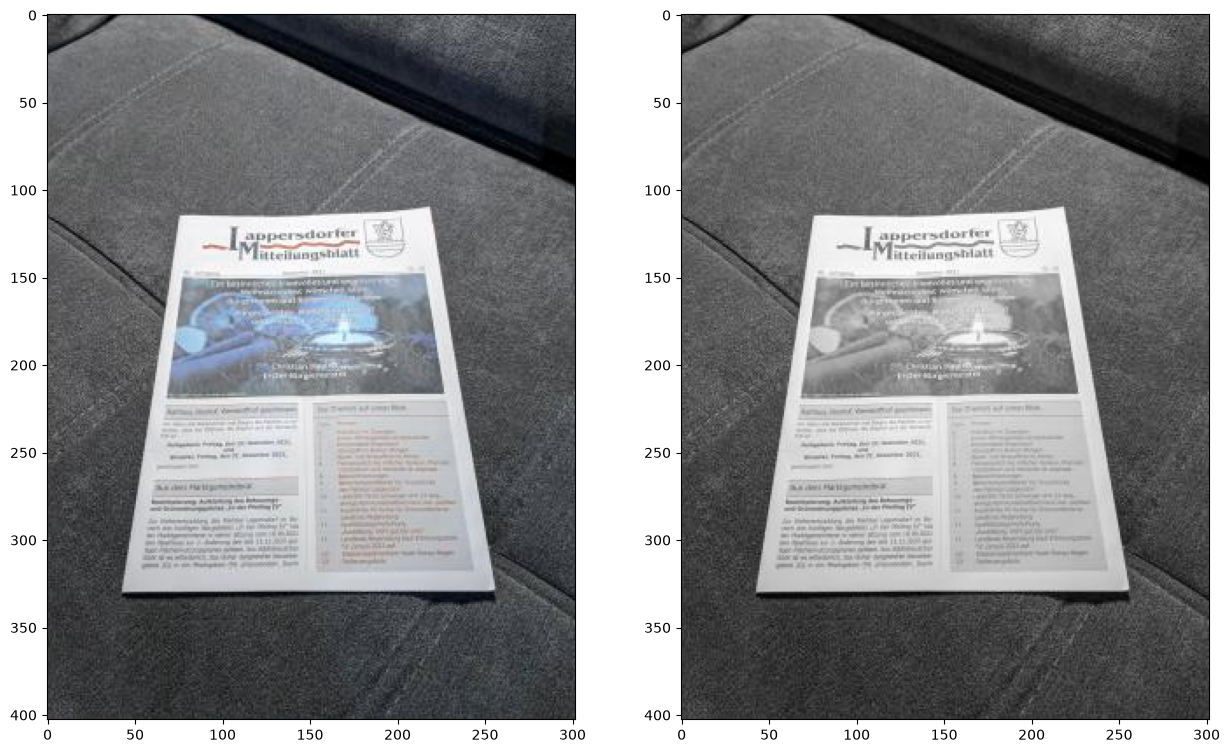

In [112]:
img = cv2.imread('../../lesson_6/data/document.jpg')
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)/255
rows, cols = gray.shape

# Let's plot the image
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(gray, cmap='gray')

In the previous homework you should have detected the four document corners and you will need to use them here. But don't worry if the previous homework did not work out for you, I am going to provide you with the corners coordinates here :-)

In [113]:
top_left = [76, 115]
top_right = [219, 111]
bottom_left = [43, 330]
bottom_right = [256, 329]

(<Axes: >, <matplotlib.image.AxesImage at 0x219c0d2fc50>)

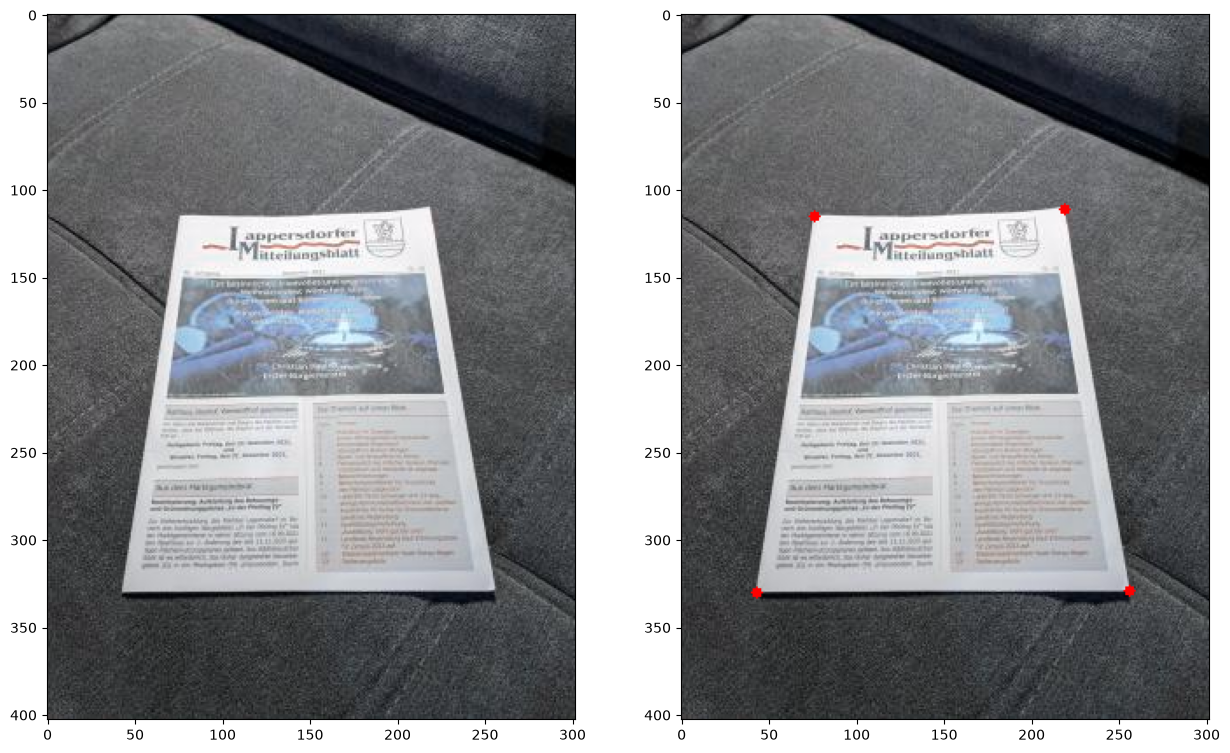

In [114]:
# Let's plot the points
out = np.copy(img)
out = cv2.circle(out, tuple(top_left), 3, (255,0,0), -1)
out = cv2.circle(out, tuple(top_right), 3, (255,0,0), -1)
out = cv2.circle(out, tuple(bottom_left), 3, (255,0,0), -1)
out = cv2.circle(out, tuple(bottom_right), 3, (255,0,0), -1)

plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(out)

### Document Rectification

Let's now try to rectify the document. The goal is to bring the four document corners to the image corners. For instance, we want the top-left document corner to become (0, 0), i.e., the top-left corner of the image itself. In that way, we will fill the complete image with document information and we will throw away parts of the images that correspond to background (which are of no use to us).

In [115]:
# Define the matrix of source points corresponding to the 4 document corners.
# The matrix shall have shape (4, 2), i.e., 4 corners x 2 coordinates
# Note: You will need to explicitly use float32 data type
src = np.array([top_left, top_right, bottom_right, bottom_left], dtype=np.float32)
print(src)
print(src.shape)

def calculate_max_distance_between_points(point_1, point_2, point_3, point_4):
    point_1 = np.array(point_1)
    point_2 = np.array(point_2)
    point_3 = np.array(point_3)
    point_4 = np.array(point_4)
    
    length_p1_p2 = np.linalg.norm(point_1 - point_2)
    length_p3_p4 = np.linalg.norm(point_3 - point_4)

    print("\ncalculate_max_distance_between_points()")
    print(f"length_p1_p2: {length_p1_p2}")
    print(f"length_p3_p4: {length_p3_p4}")
    print(f"max value: {np.maximum(length_p1_p2, length_p3_p4)}\n")
    return np.maximum(length_p1_p2, length_p3_p4)

def modify_corner_coordinates_to_make_rectangle(point_1, point_2, point_3, point_4):
    point_1 = np.array(point_1)
    point_2 = np.array(point_2)
    point_3 = np.array(point_3)
    point_4 = np.array(point_4)

    # lef corner
    if point_1[0] > point_2[0]:
        point_1[0] = point_2[0]
        
    # right corner
    if point_3[0] < point_4[0]:
        point_3[0] = point_4[0]


    return point_1, point_3

# Define the matrix of target (destination) points corresponding to the 4 image corners.
# The matrix shall have shape (4, 2), i.e., 4 corners x 2 coordinates
# Note: You will need to explicitly use float32 data type
# Note2: The order of points in src and dst must be the same

# I have decided to calculate the target width and height of the image in the following way
# 1. We can see the corners of our document and distance between top_left and top_right will give us a width of the top of the document
# 2. We can see the corners of our document and distance between bottom_left and bottom_right will give us a width of the bottom of the document
# 3. After we calculate the top and bottom width we just pick the max value to represent the width of the document
# 4. The same approach for calculating hight
#top_left,  top_right = modify_corner_coordinates_to_make_rectangle(top_left, bottom_left, top_right, bottom_right)
dst_width = calculate_max_distance_between_points(top_left, top_right, bottom_left, bottom_right)
dst_height = calculate_max_distance_between_points(top_left, bottom_left, top_right, bottom_right)

dst_top_left = [0, 0]
dst_top_right = [dst_width, 0]
dst_bottom_left = [0, dst_height]
dst_bottom_right = [dst_width, dst_height]

dst = np.array([dst_top_left, dst_top_right, dst_bottom_right, dst_bottom_left], dtype=np.float32)
print(dst)
print(dst.shape)

[[ 76. 115.]
 [219. 111.]
 [256. 329.]
 [ 43. 330.]]
(4, 2)

calculate_max_distance_between_points()
length_p1_p2: 143.05593311708537
length_p3_p4: 213.00234740490538
max value: 213.00234740490538


calculate_max_distance_between_points()
length_p1_p2: 217.51781536232843
length_p3_p4: 221.11761576138613
max value: 221.11761576138613

[[  0.        0.     ]
 [213.00235   0.     ]
 [213.00235 221.11761]
 [  0.      221.11761]]
(4, 2)


Let's first start with the affine transform for document rectification. The affine transform can be analytically calculated using 3 point pairs. Therefore, let's select the **first 3 points** and calculate the correspnding transfrom. We will then use the transform to rectify the document.

(<Axes: >, <matplotlib.image.AxesImage at 0x219c11eccd0>)

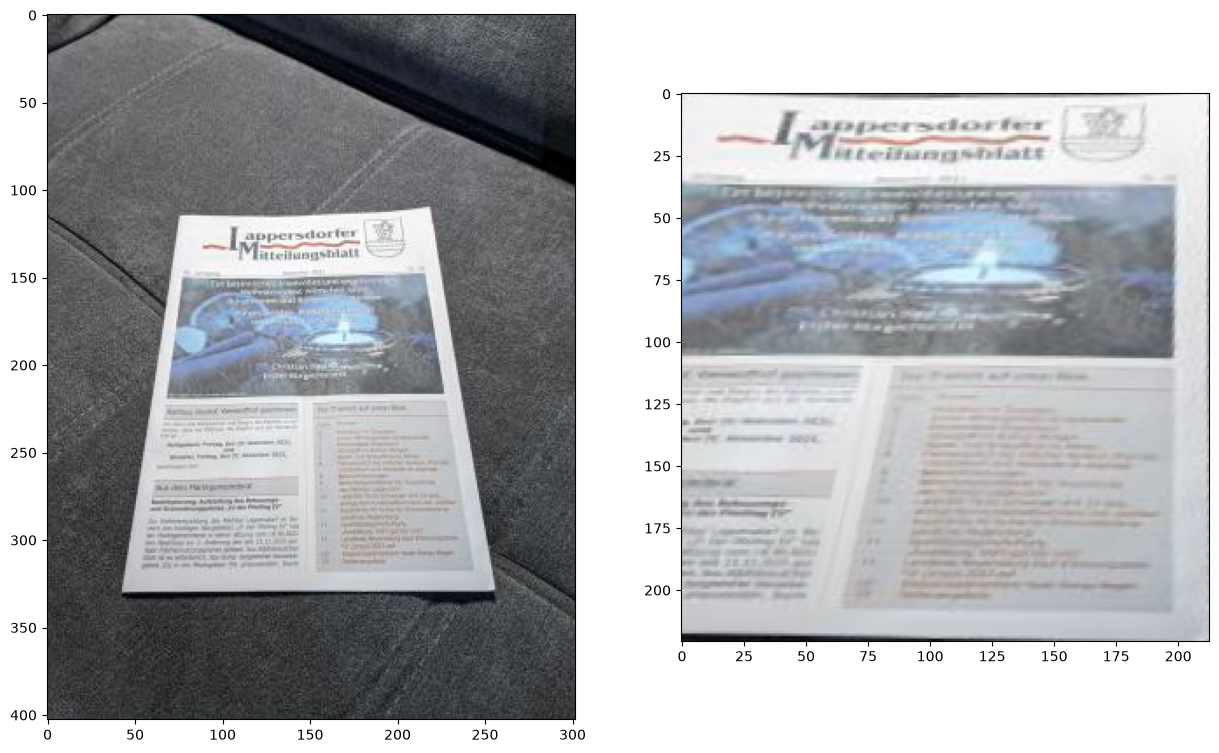

In [116]:
# Compute the affine transform matrix (you'll have to use getAffineTransform function from OpenCV here)
# Use the first 3 points from your src and dst matrix
M = cv2.getAffineTransform(src[:3], dst[:3])

# Build the rectified image using the computed matrix (you'll have to use warpAffine function from OpenCV here)
dst_size = (int(dst_width), int(dst_height))
rectified = cv2.warpAffine(img, M, dst_size)
# Let's plot the results
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(rectified)

Well, this is not bad by certainly not what we were aiming for. Let's try the **last 3** points instead.

(<Axes: >, <matplotlib.image.AxesImage at 0x219c33ae490>)

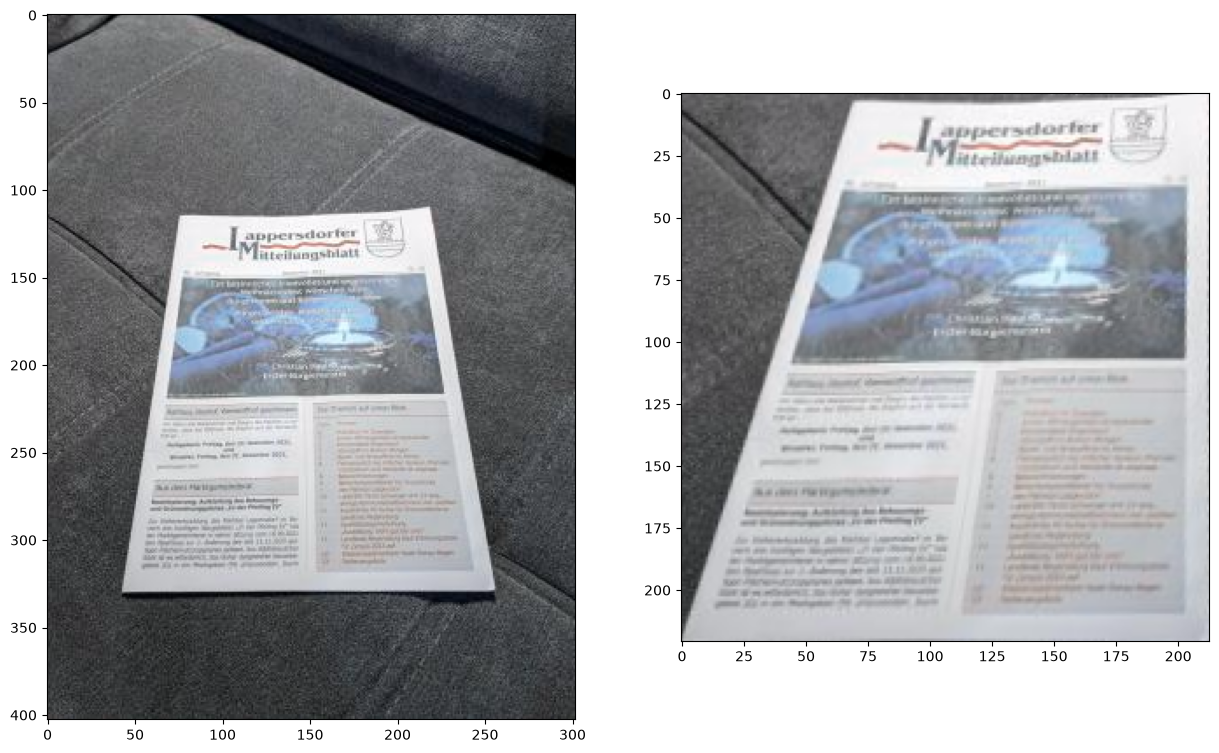

In [117]:
# Compute the affine transform matrix (use getAffineTransform)
# Use the last 3 points from your src and dst matrix
M = cv2.getAffineTransform(src[-3:], dst[-3:])

# Build the rectified image using the computed matrix (use warpAffine)
rectified = rectified = cv2.warpAffine(img, M, dst_size)

# Let's plot the results
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(rectified)

The result looks different but not better. This approach doesn't seem to be helping then. Let's use **all 4 points** and let OpenCV **estimate** (remember that 4 points are too many for an analytical solution) the best fitting affine transform for us. It'll internally apply optimization approaches as well as RANSAC.

[[1]
 [1]
 [0]
 [1]]


(<Axes: >, <matplotlib.image.AxesImage at 0x219c3817c50>)

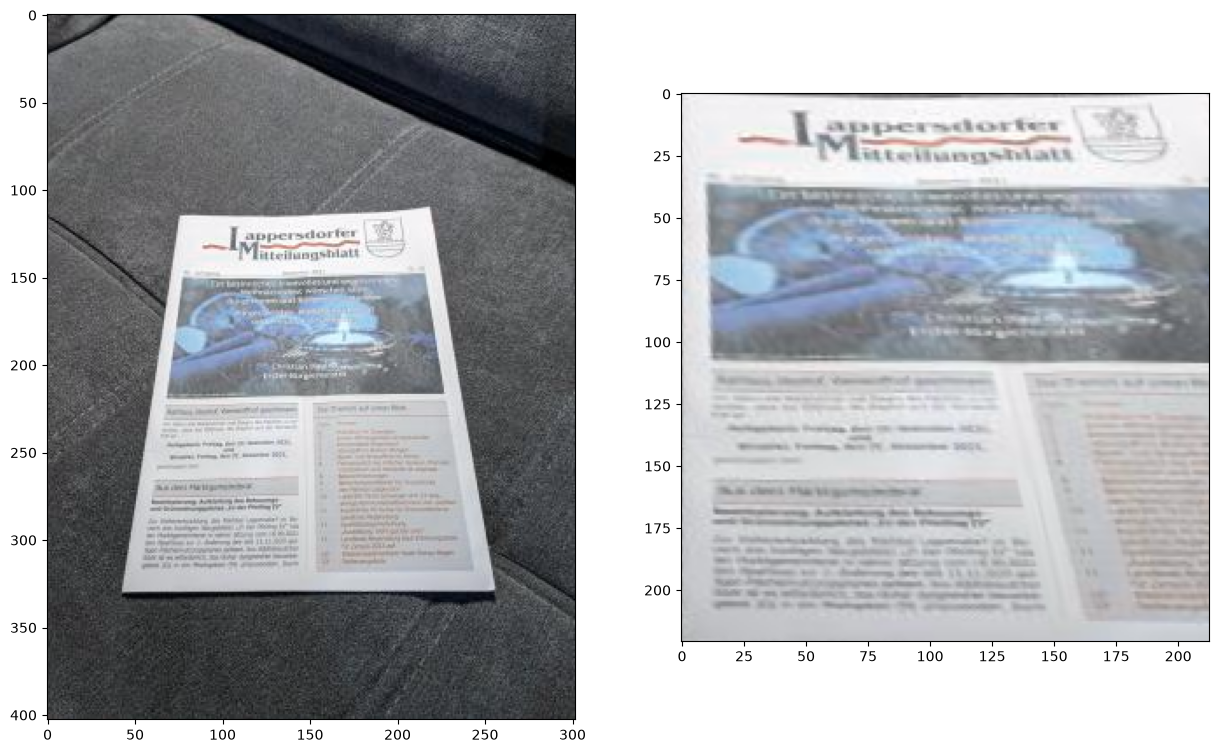

In [118]:
# Estimate the optimal affine transform matrix (you'll have to use estimateAffine2D function from OpenCV here)
# estimateAffine2D it returns the best fitting affine matrix as well as the vector of inliers (1 -> inlier,
# 0 -> outlier).
M, inliers = cv2.estimateAffine2D(src, dst)
print(inliers)

# Build the rectified image using the computed matrix (use warpAffine)
rectified = rectified = cv2.warpAffine(img, M, dst_size)

# Let's plot the results
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(rectified)

There is not much of an improvement either. Let's try homography instead of affine transform. Remember that for computing the homography analytically we need to use 4 pairs of points.

(<Axes: >, <matplotlib.image.AxesImage at 0x219c5a08cd0>)

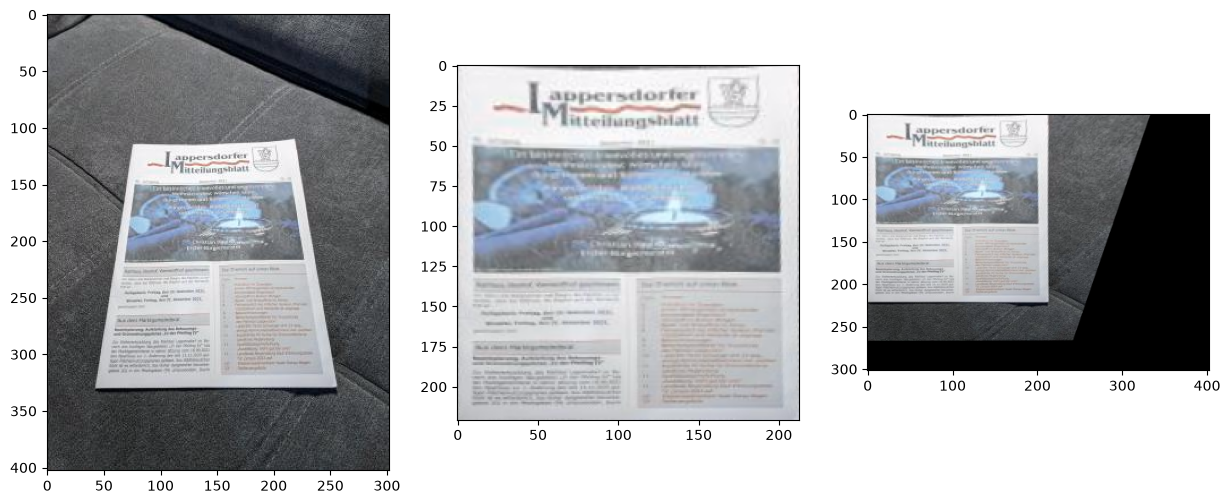

In [123]:
# Compute the homography matrix (you'll have to use getPerspectiveTransform function from OpenCV here)
M = cv2.getPerspectiveTransform(src, dst)

# Build the rectified image using the computed matrix (you'll have to use warpPerspective function from OpenCV)
rectified = cv2.warpPerspective(img, M, dst_size)
rectified_orig_size = cv2.warpPerspective(img, M, (rows, cols))


# Let's plot the results
plt.subplot(131), plt.imshow(img)
plt.subplot(132), plt.imshow(rectified)
plt.subplot(133), plt.imshow(rectified_orig_size)

### Questions
* The affine transform does not seem to be working well in this case. Why?

  A: The affine transform preserver parallelism for lines that causes undesirable results and perspective distorion
* What can you tell me about the values you have obtained for the inliers vector? What does it mean?

  A: The values obtained are 1, 1, 0, 1 - we have passed four points and after the bottom right corner point was rejected after applying RANSAC 
* How does the result from homography look? Does it work well enough?

  A: The result of homography definetelly gives us a better result comparing to the affine transformation, but we can see that resulting image looks kinda squished and stretched in width, but it still preserves the information, maybe less precise than the original picture, but some prepropcessing of the image before applying homography will give us better resuls in general. Small note, we can see that calculating approximate width and height of the resulting document by having 4 corners gives us a preety good view of the resulting image :)

Remember, I am **not** looking for a particular answer. I want to see how you think, so be creative ;-)